# Fourier Transform

This notebook provides a complete workflow to identify market cycles using the Fast Fourier Transform (FFT). We will transition from the Time Domain (price over time) to the Frequency Domain (magnitude of cycles) to identify time cycle for each stock.

📈 Stock Market Cycle Analysis with Fourier TransformThe Fourier Transform decomposes a signal into its constituent frequencies. In finance, we use it to find hidden periodicities (cycles) that are not visible to the naked eye.
🧮 Mathematical FoundationThe Discrete Fourier Transform (DFT) is defined as:$$X(k) = \sum_{n=0}^{N-1} x(n) \cdot e^{-i 2\pi k \frac{n}{N}}$$Where:$x(n)$: The price at time $n$.$X(k)$: The signal in the frequency domain.$N$: Total number of observations

### 1. Setup and install libraries

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import detrend

# Set plot style
plt.style.use('ggplot')

### 2. Data Acquisition & Pre-processing

Stock prices are non-stationary (they have a trend). To apply FFT effectively, we must detrend the data to focus strictly on the oscillations.

detrend(prices) ทำหน้าที่อะไร?คำสั่งนี้จะทำการ "ดึงแนวโน้มหลักออก" เพื่อให้เหลือแต่ "การแกว่งตัว" ครับหาเส้นแนวโน้ม (Linear Regression): มันจะคำนวณหาเส้นตรงหนึ่งเส้น ($y = mx + c$) ที่ลากผ่านข้อมูลราคาหุ้นทั้งหมดเพื่อดูว่าโดยรวมแล้วหุ้นเป็นขาขึ้นหรือขาลงเท่าไหร่ลบเส้นนั้นออก: เอาค่าราคาหุ้นจริง ลบด้วย ค่าบนเส้นแนวโน้มผลลัพธ์ (Stationary Signal): ข้อมูลที่เหลือจะกลายเป็นค่าที่แกว่งตัวรอบเส้น 0 เสมอ

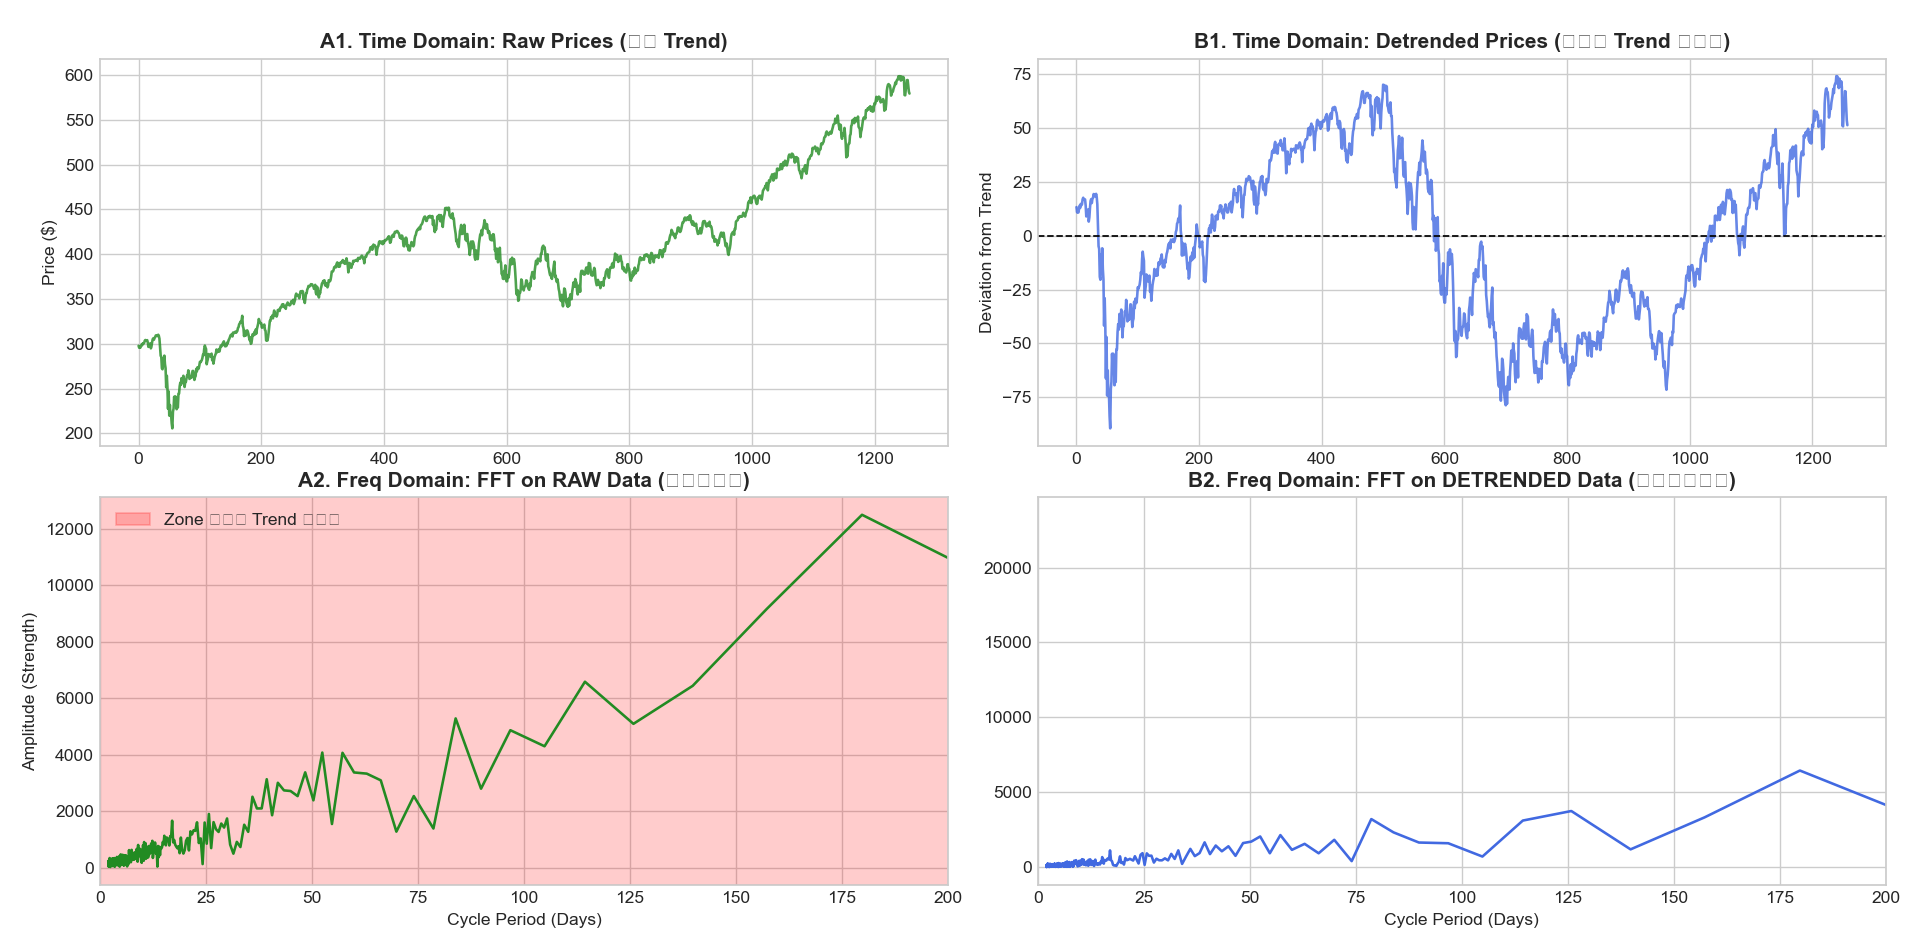

In [ ]:
# Download data
ticker = 'SPY'
df = yf.download(ticker, start="2020-01-01", end="2025-01-01")

# ROBUST DATA SELECTION
# We look for any column containing 'Close' (could be 'Adj Close' or 'Close')
close_cols = [col for col in df.columns if 'Close' in (col[0] if isinstance(col, tuple) else col)]
prices = df[close_cols[0]].dropna().values.flatten()

n = len(prices)
prices_detrended = detrend(prices)

print(prices_detrended)
print(f"Successfully loaded {n} data points using column: {close_cols[0]}")

[*********************100%***********************]  1 of 1 completed

[13.36068385 10.91272084 11.84613601 ... 60.64562612 53.74072341
 51.43182901]
Successfully loaded 1258 data points using column: ('Close', 'SPY')


### 3. Frequency Analysis (FFT)
We convert the price movements into cycles.

In [13]:
# Apply FFT
yf_output = fft(prices_detrended)
xf_freqs = fftfreq(n, d=1) 

# Focus on positive frequencies
mask = xf_freqs > 0
frequencies = xf_freqs[mask]
amplitudes = np.abs(yf_output[mask])

# Convert to Period (Days)
periods = 1 / frequencies

### 4. Visualization & Cycle Discovery

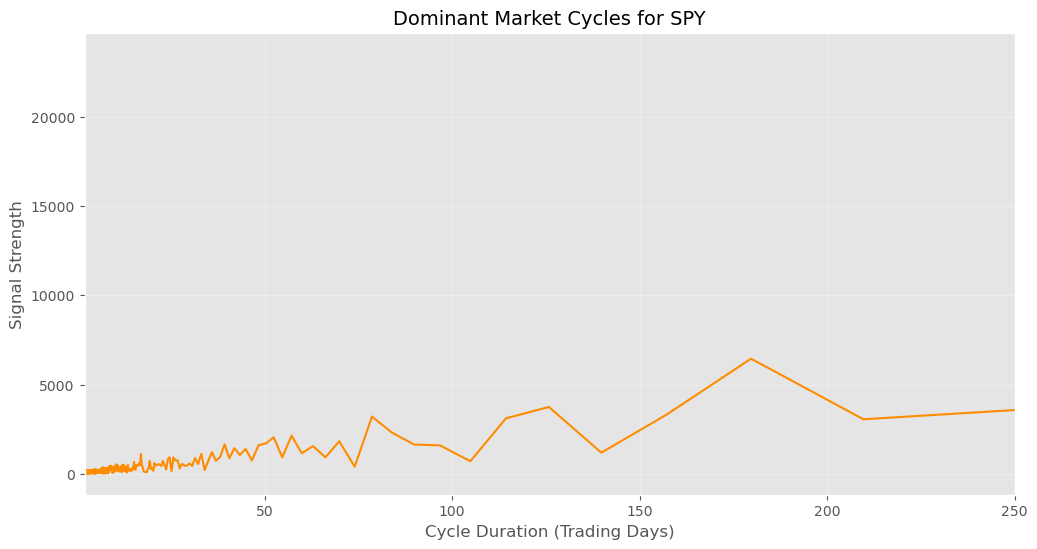

In [14]:
plt.figure(figsize=(12, 6))

# Plotting the Power Spectrum
plt.plot(periods, amplitudes, color='darkorange', linewidth=1.5)
plt.title(f'Dominant Market Cycles for {ticker}', fontsize=14)
plt.xlabel('Cycle Duration (Trading Days)', fontsize=12)
plt.ylabel('Signal Strength', fontsize=12)

# Focus on common trading cycles (between 2 and 250 days)
plt.xlim(2, 250) 
plt.grid(True, alpha=0.3)

# Annotate the strongest cycle
max_idx = np.argmax(amplitudes)
plt.annotate(f'Strongest Cycle: {periods[max_idx]:.1f} Days', 
             xy=(periods[max_idx], amplitudes[max_idx]), 
             xytext=(periods[max_idx]+20, amplitudes[max_idx]),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [15]:
# Get Top 5 Cycles
top_indices = np.argsort(amplitudes)[-5:][::-1]

print(f"{'Rank':<5} | {'Period (Days)':<15} | {'Strength':<10}")
print("-" * 35)
for i, idx in enumerate(top_indices):
    print(f"{i+1:<5} | {periods[idx]:<15.2f} | {amplitudes[idx]:<10.2f}")

Rank  | Period (Days)   | Strength  
-----------------------------------
1     | 629.00          | 23530.34  
2     | 1258.00         | 19025.95  
3     | 419.33          | 7818.22   
4     | 314.50          | 7693.17   
5     | 179.71          | 6447.25   
